<a href="https://colab.research.google.com/github/elbuh0/genai-course/blob/main/genai-course/week2/homework/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW2 — Diffusion Models: Schedules, Conditioning, and Latency

---

## Setup

In [ ]:
!pip install diffusers accelerate torch torchvision matplotlib --quiet

In [ ]:
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", DEVICE)

Device: cuda


# Part 1: Diffusion on FashionMNIST with Schedule Comparison

In [ ]:
def linear_schedule(T=1000, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, T)

def cosine_schedule(T=1000, s=0.008):
    steps = torch.arange(T+1, dtype=torch.float32)
    f = torch.cos(((steps/T + s) / (1+s)) * torch.pi/2) ** 2
    alphas_bar = f / f[0]
    betas = 1 - (alphas_bar[1:] / alphas_bar[:-1])
    return torch.clamp(betas, 0, 0.999)

In [ ]:
# Implement `q_sample(x0, t, betas)` — the closed-form forward process.
#Formula: x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * eps where eps ~ N(0,I) and alpha_bar_t = prod(1 - beta_i for i in 1..t) Hint: precompute alpha_bar from betas.

def q_sample(x0, t, betas):
    # Compute alpha_t = 1 - beta_t
    alphas = 1.0 - betas

    # Compute cumulative product:
    # alpha_bar_t = alpha_1 * alpha_2 * ... * alpha_t
    alpha_bars = torch.cumprod(alphas, dim=0)

    # Get alpha_bar for the requested timestep(s)
    alpha_bar_t = alpha_bars[t]

    # Reshape for broadcasting over image dimensions
    alpha_bar_t = alpha_bar_t.view(-1, 1, 1, 1)

    # Sample Gaussian noise: epsilon ~ N(0, I)
    eps = torch.randn_like(x0)

    # Closed-form forward diffusion process
    x_t = (
        torch.sqrt(alpha_bar_t) * x0
        + torch.sqrt(1.0 - alpha_bar_t) * eps
    )

    return x_t, eps


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 208kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.5MB/s]


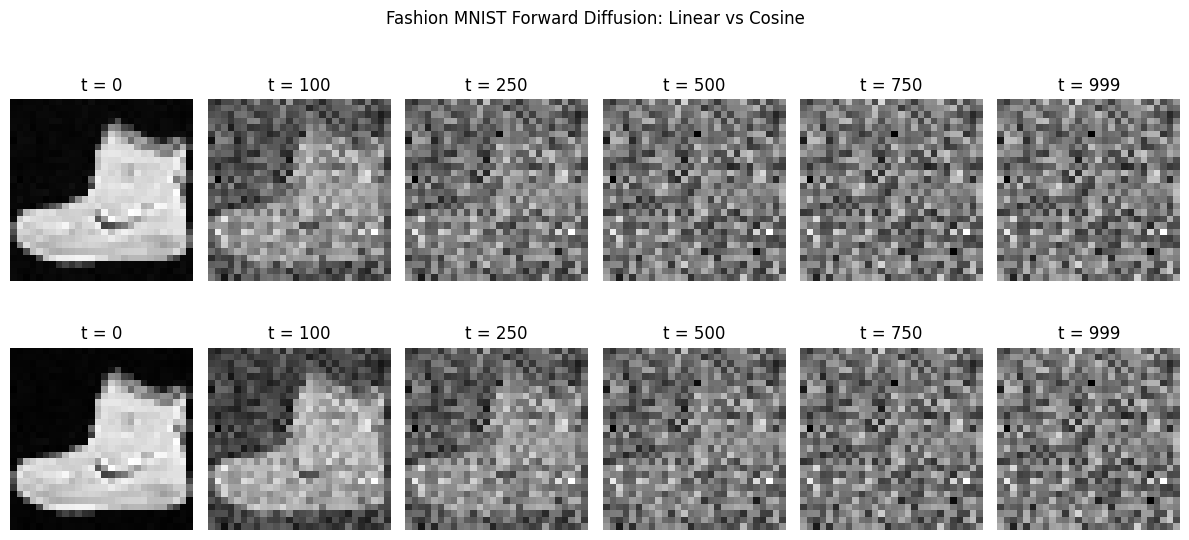

In [ ]:
# Visualise the noising process: take one Fashion MNIST image, show it at t=0, 250, 500, 750, 1000 for BOTH linear and cosine schedules side by side. Which schedule destroys fine detail faster?

from torch.serialization import T
import torch, torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

class NoiseSchedule:
  def __init__(self, T=1000, schedule="linear", device="cuda"):
    self.T = T
    if schedule == "linear":
      betas = torch.linspace(1e-4, 0.02, T) # b1 ... b_T
    elif schedule == "cosine":
      # Improved DDPM (Nichol & Dhariwal 2021)
      s = 0.008
      steps = torch.arange(T+1, dtype=torch.float32) / T
      alphas_cumprod = torch.cos((steps + s) / (1+s) * torch.pi/2) ** 2
      alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
      betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
      betas = torch.clamp(betas, 0, 0.999)

    self.betas = betas.to(device)
    self.alphas = 1 - self.betas
    self.alphas_cumprod = torch.cumprod(self.alphas, 0).to(device)

  def q_sample(self, x0, t, noise=None):
    if noise is None:
      noise = torch.randn_like(x0)
    at = self.alphas_cumprod[t].view(-1, 1, 1, 1)
    return torch.sqrt(at) * x0 + torch.sqrt(1-at) * noise, noise


# Load one Fashion MNIST image
transform = transforms.ToTensor()
dataset = datasets.FashionMNIST("./data", train=True, download=True, transform=transform)

x0, _ = dataset[0]
x0 = x0.unsqueeze(0).to(DEVICE)

# Create linear and cosine schedules
linear = NoiseSchedule(T=1000, schedule="linear", device=DEVICE)
cosine = NoiseSchedule(T=1000, schedule="cosine", device=DEVICE)

# Timesteps to show
timesteps = [0, 100, 250, 500, 750, 999]

# Use the same noise for both schedules
noise = torch.randn_like(x0)

fig, axes = plt.subplots(2, 6, figsize=(12, 6))

# Linear schedule
for i, t in enumerate(timesteps):
    xt, _ = linear.q_sample(
        x0,
        torch.tensor([t], device=DEVICE),
        noise=noise
    )

    axes[0, i].imshow(xt[0, 0].detach().cpu(), cmap="gray")
    axes[0, i].set_title(f"t = {t}")
    axes[0, i].axis("off")

axes[0, 0].set_ylabel("Linear", fontsize=12)

# Cosine schedule
for i, t in enumerate(timesteps):
    xt, _ = cosine.q_sample(
        x0,
        torch.tensor([t], device=DEVICE),
        noise=noise
    )

    axes[1, i].imshow(xt[0, 0].detach().cpu(), cmap="gray")
    axes[1, i].set_title(f"t = {t}")
    axes[1, i].axis("off")

axes[1, 0].set_ylabel("Cosine", fontsize=12)

plt.suptitle("Fashion MNIST Forward Diffusion: Linear vs Cosine")
plt.tight_layout()
plt.show()


In [ ]:
# U-Net Noise Predictor
class SinusoidalTimeEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-torch.arange(half, device=t.device) * (torch.log(torch.tensor(10000.0)) / (half-1)))
        args  = t[:, None].float() * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

class ResBlock(nn.Module):
  def __init__(self, in_ch, out_ch, time_dim=128):
    super().__init__()
    self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
    self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
    self.time_proj = nn.Linear(time_dim, out_ch)

    self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    self.norm1 = nn.GroupNorm(min(8, in_ch), in_ch)
    self.norm2 = nn.GroupNorm(min(8, out_ch), out_ch)

  def forward(self, x, t_emb):
    h = F.silu(self.norm1(x))
    h = self.conv1(h) + self.time_proj(t_emb)[:, :, None, None]

    h = F.silu(self.norm2(h))
    h = self.conv2(h)

    return h + self.skip(x)

In [ ]:
# UNet class with encoder, bottleneck, decoder, and time embeddings

class TimeEmbedding(nn.Module):
  def __init__(self, dim):
    super().__init__()
    self.mlp = nn.Sequential(nn.Linear(dim, dim*4), nn.SiLU(), nn.Linear(dim*4, dim))

  def forward(self, t, dim=128):
      half = dim // 2
      freq = torch.exp(-torch.arange(half, device=t.device) * (8.0/half))
      args = t[:, None].float() * freq[None]
      embedding = torch.cat([torch.cos(args), torch.sin(args)], -1)
      return self.mlp(embedding)

class ResBlock(nn.Module):
  def __init__(self, in_ch, out_ch, time_dim=128):
    super().__init__()
    self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
    self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
    self.time_proj = nn.Linear(time_dim, out_ch) # adds time info as bias
    self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    self.norm1 = nn.GroupNorm(8, in_ch)
    self.norm2 = nn.GroupNorm(8, out_ch)

  def forward(self, x, t_emb):
    h = F.silu(self.norm1(x))
    h = self.conv1(h) + self.time_proj(t_emb)[:, :, None, None]

    h = F.silu(self.norm2(h))
    h = self.conv2(h)
    return h + self.skip(x) # residual connection

class SimpleUNet(nn.Module):
  def __init__(self, channels=[32,64,128], time_dim=128):
      super().__init__()
      self.time_embed = TimeEmbedding(time_dim)
      self.down = nn.ModuleList() # encoder
      self.up   = nn.ModuleList() # decoder
      in_ch = 1 # Fashion MNIST is grayscale

      for ch in channels:
        self.down.append(ResBlock(in_ch, ch, time_dim))
        in_ch = ch

      self.bottleneck = ResBlock(channels[-1], channels[-1], time_dim)

      in_ch = channels[-1]*2
      for ch in reversed(channels):
        self.up.append(ResBlock(in_ch + ch, ch, time_dim)) # +ch for skip
        in_ch = ch

      self.final = nn.Conv2d(channels[0], 1, 1) # predict noise

  def forward(self, x, t):
      t_emb = self.time_embed(t)
      skips = []

      for block in self.down:
          x = block(x, t_emb)
          skips.append(x)
          x = F.max_pool2d(x, 2)

      x = self.bottleneck(x, t_emb)

      for block, skip in zip(self.up, reversed(skips)):
        x = F.interpolate(x, size=skip.shape[-2:], mode="nearest")
        x = block(torch.cat([x, skip], 1), t_emb) # paste skip connection

      return self.final(x) # predicted noise epsilon_theta


In [ ]:
# Training function

def train(model, schedule, loader, epochs=40, device=DEVICE,
          schedule_name="Linear", ckpt_epochs=(5, 10, 20, 30, 40)):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-4)

    losses = []
    checkpoints = {}

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0

        for x0, _ in loader:
            x0 = x0.to(device)

            # Sample random timestep t for each image in batch
            t = torch.randint(0, schedule.T, (x0.shape[0],), device=device)

            # Get noisy image and the actual noise added
            xt, noise = schedule.q_sample(x0, t)

            # Predict noise epsilon_theta(x_t, t)
            pred_noise = model(xt, t)

            # MSE between actual and predicted noise
            loss = F.mse_loss(pred_noise, noise)

            opt.zero_grad()
            loss.backward()
            opt.step()

            epoch_loss += loss.item()

        avg = epoch_loss / len(loader)
        losses.append(avg)

        print(f"Epoch {epoch:3d}/{epochs} | loss: {avg:.4f}")

        # Snapshot weights at the checkpoint epochs
        if epoch in ckpt_epochs:
            checkpoints[epoch] = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

    # Plot training loss
    plt.figure(figsize=(7, 4))
    plt.plot(range(1, epochs + 1), losses)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"UNet DDPM Training Loss - {schedule_name} Schedule")
    plt.grid(alpha=0.3)
    plt.show()

    return losses, checkpoints

Epoch  1/40 | Loss: 0.0930
Epoch  2/40 | Loss: 0.0407
Epoch  3/40 | Loss: 0.0357
Epoch  4/40 | Loss: 0.0329
Epoch  5/40 | Loss: 0.0313
Epoch  6/40 | Loss: 0.0304
Epoch  7/40 | Loss: 0.0296
Epoch  8/40 | Loss: 0.0284
Epoch  9/40 | Loss: 0.0280
Epoch 10/40 | Loss: 0.0278
Epoch 11/40 | Loss: 0.0274
Epoch 12/40 | Loss: 0.0269
Epoch 13/40 | Loss: 0.0265
Epoch 14/40 | Loss: 0.0263
Epoch 15/40 | Loss: 0.0264
Epoch 16/40 | Loss: 0.0261
Epoch 17/40 | Loss: 0.0258
Epoch 18/40 | Loss: 0.0254
Epoch 19/40 | Loss: 0.0253
Epoch 20/40 | Loss: 0.0252
Epoch 21/40 | Loss: 0.0246
Epoch 22/40 | Loss: 0.0245
Epoch 23/40 | Loss: 0.0252
Epoch 24/40 | Loss: 0.0246
Epoch 25/40 | Loss: 0.0247
Epoch 26/40 | Loss: 0.0243
Epoch 27/40 | Loss: 0.0248
Epoch 28/40 | Loss: 0.0243
Epoch 29/40 | Loss: 0.0235
Epoch 30/40 | Loss: 0.0242
Epoch 31/40 | Loss: 0.0240
Epoch 32/40 | Loss: 0.0236
Epoch 33/40 | Loss: 0.0241
Epoch 34/40 | Loss: 0.0239
Epoch 35/40 | Loss: 0.0240
Epoch 36/40 | Loss: 0.0235
Epoch 37/40 | Loss: 0.0237
E

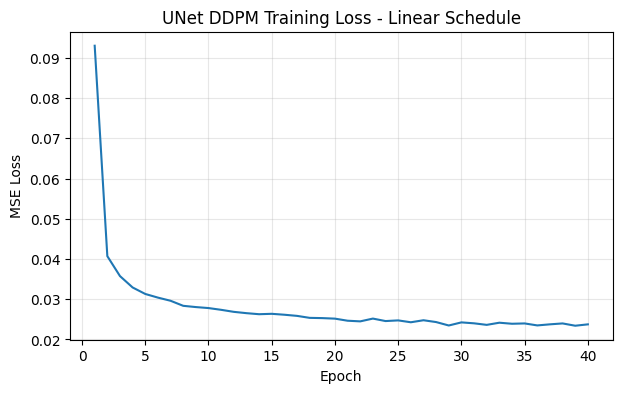

Training time: 17.3 min


In [ ]:
# Variant A: Linear Schedule

import time
import torch.nn.functional as F

class TimeEmbedding(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.SiLU(),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, t):
        half = 128 // 2
        freq = torch.exp(
            -torch.arange(half, device=t.device) * (8.0 / half)
        )
        args = t[:, None].float() * freq[None]
        embedding = torch.cat(
            [torch.cos(args), torch.sin(args)], dim=-1
        )
        return self.mlp(embedding)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim=128):
        super().__init__()

        self.norm1 = nn.GroupNorm(min(8, in_ch), in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        self.norm2 = nn.GroupNorm(min(8, out_ch), out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.time_proj = nn.Linear(time_dim, out_ch)

        self.skip = (
            nn.Conv2d(in_ch, out_ch, 1)
            if in_ch != out_ch else nn.Identity()
        )

    def forward(self, x, t_emb):
        h = F.silu(self.norm1(x))
        h = self.conv1(h)

        h = h + self.time_proj(t_emb)[:, :, None, None]

        h = F.silu(self.norm2(h))
        h = self.conv2(h)

        return h + self.skip(x)


class SimpleUNet(nn.Module):
    def __init__(self, time_dim=128):
        super().__init__()

        self.time_embed = TimeEmbedding(time_dim)

        # Encoder: 1 → 32 → 64 → 128
        self.down1 = ResBlock(1, 32, time_dim)
        self.down2 = ResBlock(32, 64, time_dim)
        self.down3 = ResBlock(64, 128, time_dim)

        # Bottleneck
        self.bottleneck = ResBlock(128, 128, time_dim)

        # Decoder
        self.up1 = ResBlock(128 + 128, 128, time_dim)
        self.up2 = ResBlock(128 + 64, 64, time_dim)
        self.up3 = ResBlock(64 + 32, 32, time_dim)

        # Predict one-channel noise
        self.final = nn.Conv2d(32, 1, 1)

    def forward(self, x, t):
        t_emb = self.time_embed(t)

        # Encoder
        x1 = self.down1(x, t_emb)
        x2 = self.down2(F.max_pool2d(x1, 2), t_emb)
        x3 = self.down3(F.max_pool2d(x2, 2), t_emb)

        # Bottleneck
        x = self.bottleneck(F.max_pool2d(x3, 2), t_emb)

        # Decoder + skip connections
        x = F.interpolate(x, size=x3.shape[-2:], mode="nearest")
        x = self.up1(torch.cat([x, x3], dim=1), t_emb)

        x = F.interpolate(x, size=x2.shape[-2:], mode="nearest")
        x = self.up2(torch.cat([x, x2], dim=1), t_emb)

        x = F.interpolate(x, size=x1.shape[-2:], mode="nearest")
        x = self.up3(torch.cat([x, x1], dim=1), t_emb)

        return self.final(x)


def train(model, schedule, loader, epochs=40, device=DEVICE,
          schedule_name="Linear", ckpt_epochs=(5, 10, 20, 30, 40), fresh=True):
    # Re-initialise every layer so training always starts from scratch
    if fresh:
        for m in model.modules():
            if hasattr(m, "reset_parameters"):
                m.reset_parameters()

    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    losses = []
    checkpoints = {}

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0

        for x0, _ in loader:
            x0 = x0.to(device)

            # Random timestep for each image
            t = torch.randint(0, schedule.T, (x0.shape[0],), device=device)

            # Add noise according to the schedule
            x_t, noise = schedule.q_sample(x0, t)

            # Predict the noise
            pred_noise = model(x_t, t)

            # Compare predicted noise with true noise
            loss = F.mse_loss(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        losses.append(avg_loss)

        print(f"Epoch {epoch:2d}/{epochs} | Loss: {avg_loss:.4f}")

        # Save model at the requested epochs
        if epoch in ckpt_epochs:
            checkpoints[epoch] = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

    # Plot training loss
    plt.figure(figsize=(7, 4))
    plt.plot(range(1, epochs + 1), losses)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"UNet DDPM Training Loss - {schedule_name} Schedule")
    plt.grid(alpha=0.3)
    plt.show()

    return losses, checkpoints


# Create the Fashion MNIST loader
loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

# Create model and linear noise schedule
model = SimpleUNet().to(DEVICE)

schedule = NoiseSchedule(
    T=1000,
    schedule="linear",
    device=DEVICE
)

# Train once from scratch (timed), checkpoints at 5, 10, 20, 30, 40
train_times = globals().get("train_times", {})   # shared dict across cells

t0 = time.time()
linear_losses, linear_checkpoints = train(
    model, schedule, loader,
    epochs=40, device=DEVICE,
    schedule_name="Linear",
    ckpt_epochs=(5, 10, 20, 30, 40)
)
train_times["Linear"] = time.time() - t0
print(f"Training time: {train_times['Linear'] / 60:.1f} min")

Epoch  1/40 | Loss: 0.1415
Epoch  2/40 | Loss: 0.0707
Epoch  3/40 | Loss: 0.0629
Epoch  4/40 | Loss: 0.0587
Epoch  5/40 | Loss: 0.0563
Epoch  6/40 | Loss: 0.0531
Epoch  7/40 | Loss: 0.0526
Epoch  8/40 | Loss: 0.0518
Epoch  9/40 | Loss: 0.0509
Epoch 10/40 | Loss: 0.0498
Epoch 11/40 | Loss: 0.0496
Epoch 12/40 | Loss: 0.0485
Epoch 13/40 | Loss: 0.0490
Epoch 14/40 | Loss: 0.0486
Epoch 15/40 | Loss: 0.0480
Epoch 16/40 | Loss: 0.0474
Epoch 17/40 | Loss: 0.0470
Epoch 18/40 | Loss: 0.0467
Epoch 19/40 | Loss: 0.0468
Epoch 20/40 | Loss: 0.0463
Epoch 21/40 | Loss: 0.0461
Epoch 22/40 | Loss: 0.0455
Epoch 23/40 | Loss: 0.0459
Epoch 24/40 | Loss: 0.0456
Epoch 25/40 | Loss: 0.0456
Epoch 26/40 | Loss: 0.0451
Epoch 27/40 | Loss: 0.0455
Epoch 28/40 | Loss: 0.0451
Epoch 29/40 | Loss: 0.0443
Epoch 30/40 | Loss: 0.0447
Epoch 31/40 | Loss: 0.0446
Epoch 32/40 | Loss: 0.0444
Epoch 33/40 | Loss: 0.0448
Epoch 34/40 | Loss: 0.0439
Epoch 35/40 | Loss: 0.0440
Epoch 36/40 | Loss: 0.0444
Epoch 37/40 | Loss: 0.0440
E

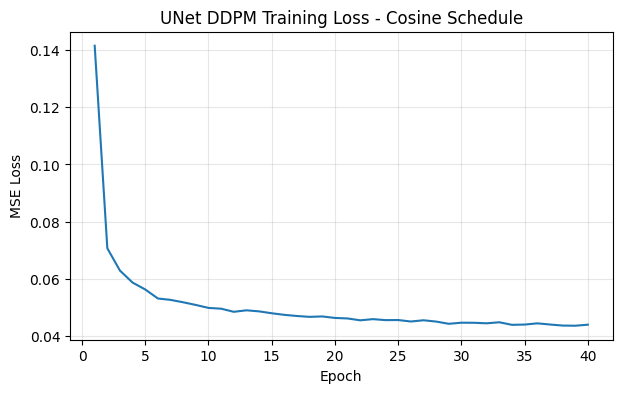

Training time: 17.3 min


In [ ]:
# Variant B: Cosine schedule
import time
train_times = globals().get("train_times", {})   # shared dict across cells

cosine_model = SimpleUNet().to(DEVICE)

cosine_schedule = NoiseSchedule(
    T=1000,
    schedule="cosine",
    device=DEVICE
)

# Train once from scratch (timed), checkpoints at 5, 10, 20, 30, 40
t0 = time.time()
cosine_losses, cosine_checkpoints = train(
    cosine_model, cosine_schedule, loader,
    epochs=40, device=DEVICE,
    schedule_name="Cosine",
    ckpt_epochs=(5, 10, 20, 30, 40)
)
train_times["Cosine"] = time.time() - t0
print(f"Training time: {train_times['Cosine'] / 60:.1f} min")

beta_1  s=0.008: 0.000041 | s=0.04: 0.000185
Epoch  1/40 | Loss: 0.1280
Epoch  2/40 | Loss: 0.0627
Epoch  3/40 | Loss: 0.0554
Epoch  4/40 | Loss: 0.0514
Epoch  5/40 | Loss: 0.0497
Epoch  6/40 | Loss: 0.0477
Epoch  7/40 | Loss: 0.0463
Epoch  8/40 | Loss: 0.0455
Epoch  9/40 | Loss: 0.0445
Epoch 10/40 | Loss: 0.0444
Epoch 11/40 | Loss: 0.0436
Epoch 12/40 | Loss: 0.0431
Epoch 13/40 | Loss: 0.0423
Epoch 14/40 | Loss: 0.0424
Epoch 15/40 | Loss: 0.0415
Epoch 16/40 | Loss: 0.0413
Epoch 17/40 | Loss: 0.0413
Epoch 18/40 | Loss: 0.0410
Epoch 19/40 | Loss: 0.0407
Epoch 20/40 | Loss: 0.0404
Epoch 21/40 | Loss: 0.0400
Epoch 22/40 | Loss: 0.0403
Epoch 23/40 | Loss: 0.0400
Epoch 24/40 | Loss: 0.0393
Epoch 25/40 | Loss: 0.0396
Epoch 26/40 | Loss: 0.0392
Epoch 27/40 | Loss: 0.0391
Epoch 28/40 | Loss: 0.0390
Epoch 29/40 | Loss: 0.0388
Epoch 30/40 | Loss: 0.0389
Epoch 31/40 | Loss: 0.0389
Epoch 32/40 | Loss: 0.0388
Epoch 33/40 | Loss: 0.0383
Epoch 34/40 | Loss: 0.0381
Epoch 35/40 | Loss: 0.0376
Epoch 36/4

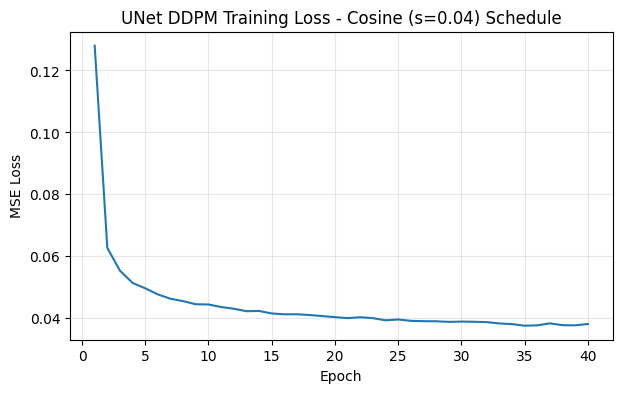

Training time: 17.3 min


In [ ]:
# Variant C: Cosine schedule with a noisier start (s = 0.04)
import time
train_times = globals().get("train_times", {})   # shared dict across cells

# Build cosine schedule with s = 0.04
T = 1000
s = 0.04

cosine_s04_schedule = NoiseSchedule(T=T, schedule="cosine", device=DEVICE)

steps = torch.arange(T + 1, dtype=torch.float32) / T
ac = torch.cos((steps + s) / (1 + s) * torch.pi / 2) ** 2
ac = ac / ac[0]
betas = torch.clamp(1 - ac[1:] / ac[:-1], 0, 0.999)

cosine_s04_schedule.betas = betas.to(DEVICE)
cosine_s04_schedule.alphas = 1 - cosine_s04_schedule.betas
cosine_s04_schedule.alphas_cumprod = torch.cumprod(cosine_s04_schedule.alphas, 0)

# Sanity check: first-step noise should be ~4.5x the s=0.008 schedule
print(f"beta_1  s=0.008: {cosine_schedule.betas[0].item():.6f} | "
      f"s=0.04: {cosine_s04_schedule.betas[0].item():.6f}")

# Model
cosine_s04_model = SimpleUNet().to(DEVICE)

# Train once from scratch (timed), checkpoints at 5, 10, 20, 30, 40
t0 = time.time()
cosine_s04_losses, cosine_s04_checkpoints = train(
    cosine_s04_model, cosine_s04_schedule, loader,
    epochs=40, device=DEVICE,
    schedule_name="Cosine (s=0.04)",
    ckpt_epochs=(5, 10, 20, 30, 40)
)
train_times["Cosine (s=0.04)"] = time.time() - t0
print(f"Training time: {train_times['Cosine (s=0.04)'] / 60:.1f} min")

In [ ]:
print(train_times)

{'Linear': 1036.8615794181824, 'Cosine': 1037.354240179062, 'Cosine (s=0.04)': 1037.7529945373535}


In [ ]:
@torch.no_grad()
def ddpm_sample(model, betas, T, x_initial):
    alphas = 1 - betas
    alpha_bars = torch.cumprod(alphas, dim=0).to(DEVICE)

    x = x_initial  # start from pure noise

    for t in reversed(range(T)):
        t_tensor = torch.tensor([t] * x.shape[0], device=DEVICE)

        # Model predicts the noise currently present in x
        eps_pred = model(x, t_tensor)

        # Posterior mean
        coef1 = betas[t] / (1 - alpha_bars[t]).sqrt()
        x = (1 / alphas[t].sqrt()) * (x - coef1 * eps_pred)

        if t > 0:
            x = x + betas[t].sqrt() * torch.randn_like(x)

    return x

Sampling Linear, epoch 10 ...
Sampling Linear, epoch 20 ...
Sampling Linear, epoch 30 ...
Sampling Linear, epoch 40 ...
Sampling Cosine, epoch 10 ...
Sampling Cosine, epoch 20 ...
Sampling Cosine, epoch 30 ...
Sampling Cosine, epoch 40 ...
Sampling Cosine (s=0.04), epoch 10 ...
Sampling Cosine (s=0.04), epoch 20 ...
Sampling Cosine (s=0.04), epoch 30 ...
Sampling Cosine (s=0.04), epoch 40 ...


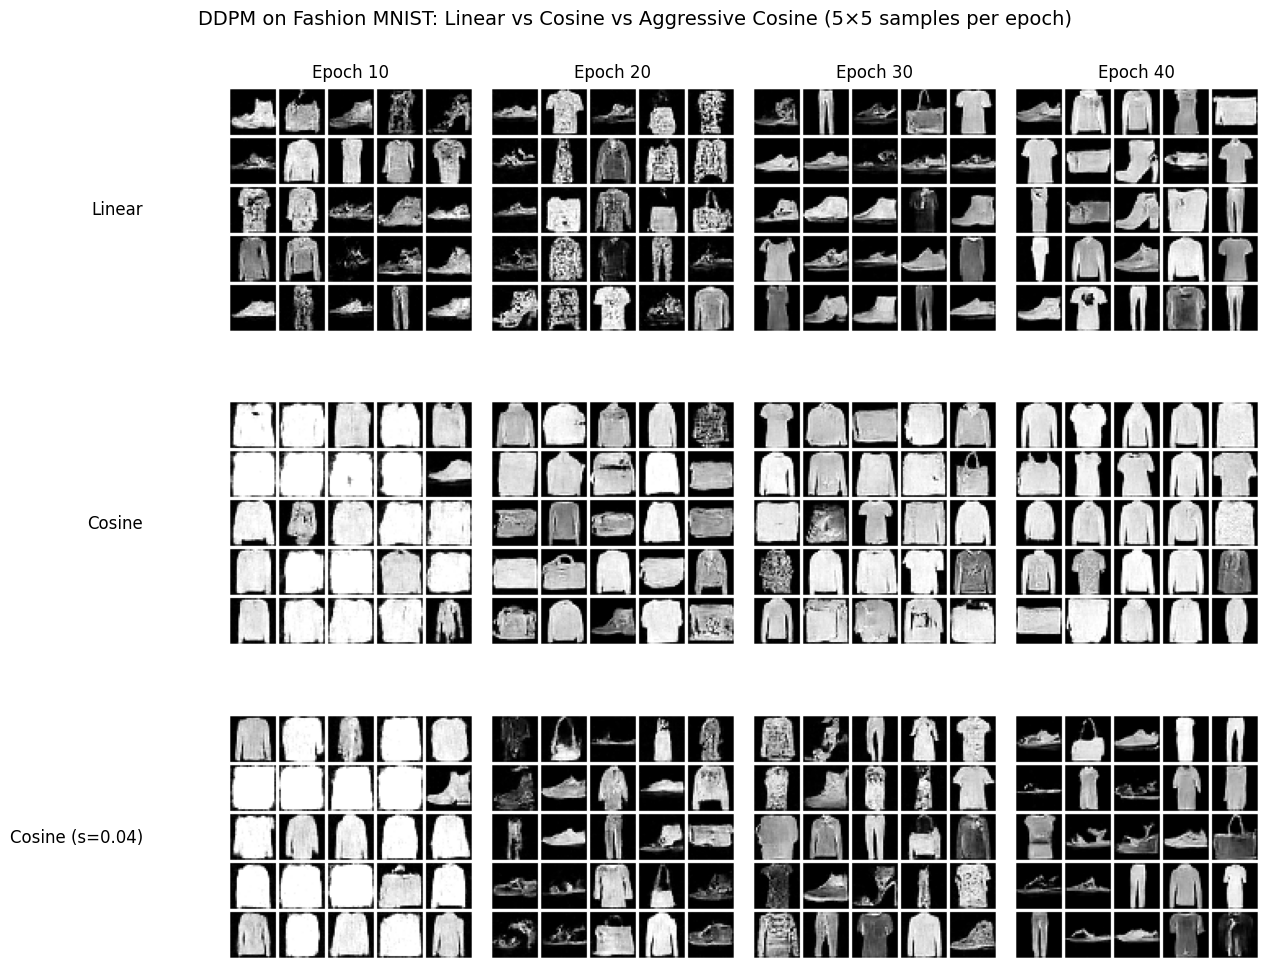

In [ ]:
# DDPM variant comparison: 5x5 sample grids at epochs 10, 20, 30, 40
import copy
from torchvision.utils import make_grid, save_image

@torch.no_grad()
def variant_grids(base_model, variants, epochs=(10, 20, 30, 40), n=5, seed=0):
    # Same 25 starting noises for every variant and epoch
    torch.manual_seed(seed)
    noise = torch.randn(n * n, 1, 28, 28, device=DEVICE)

    # Work on a copy so the trained models in memory aren't overwritten
    net = copy.deepcopy(base_model).to(DEVICE)

    fig, axes = plt.subplots(len(variants), len(epochs),
                             figsize=(3.2 * len(epochs), 3.4 * len(variants)),
                             squeeze=False)

    for r, (name, ckpts, sched) in enumerate(variants):
        slug = name.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("=", "")
        for c, ep in enumerate(epochs):
            ax = axes[r, c]
            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values():
                sp.set_visible(False)

            if ep not in ckpts:
                ax.text(0.5, 0.5, f"no epoch {ep}\ncheckpoint",
                        ha="center", va="center", transform=ax.transAxes)
            else:
                print(f"Sampling {name}, epoch {ep} ...")
                net.load_state_dict(ckpts[ep])
                net.eval()

                # ddpm_sample handles batches: all 25 samples in one run
                samples = ddpm_sample(net, sched.betas, sched.T,
                                      x_initial=noise.clone()).clamp(0, 1).cpu()

                grid = make_grid(samples, nrow=n, padding=2, pad_value=1.0)
                ax.imshow(grid[0], cmap="gray", vmin=0, vmax=1)
                save_image(grid, f"grid_{slug}_ep{ep}.png")   # each 5x5 grid as its own file

            if r == 0:
                ax.set_title(f"Epoch {ep}", fontsize=12)
            if c == 0:
                ax.set_ylabel(name, fontsize=12, rotation=0,
                              labelpad=60, ha="right", va="center")

    fig.suptitle("DDPM on Fashion MNIST: Linear vs Cosine vs Aggressive Cosine (5×5 samples per epoch)",
                 fontsize=14)
    plt.tight_layout()
    plt.savefig("variant_grids_by_epoch.png", dpi=150, bbox_inches="tight")
    plt.show()


variants = [
    ("Linear",          linear_checkpoints,     schedule),
    ("Cosine",          cosine_checkpoints,     cosine_schedule),
    ("Cosine (s=0.04)", cosine_s04_checkpoints, cosine_s04_schedule),
]

variant_grids(model, variants)

In [ ]:
# Diagnostic: is there real progression between checkpoints?
import copy

variants = [
    ("Linear",          linear_losses,     linear_checkpoints,     schedule),
    ("Cosine",          cosine_losses,     cosine_checkpoints,     cosine_schedule),
    ("Cosine (s=0.04)", cosine_s04_losses, cosine_s04_checkpoints, cosine_s04_schedule),
]
net = copy.deepcopy(model).to(DEVICE)

# Fixed held-out batch (Fashion-MNIST test set), fixed noise, fixed timesteps
test_set = datasets.FashionMNIST("./data", train=False, download=True, transform=transforms.ToTensor())
x_test = torch.stack([test_set[i][0] for i in range(512)]).to(DEVICE)
g = torch.Generator(device=DEVICE).manual_seed(0)
eps_test = torch.randn(x_test.shape, device=DEVICE, generator=g)
T_EVAL = [50, 250, 500, 750]

@torch.no_grad()
def heldout_error(sched, t_val):
    t = torch.full((x_test.shape[0],), t_val, device=DEVICE, dtype=torch.long)
    x_t, _ = sched.q_sample(x_test, t, noise=eps_test)
    return F.mse_loss(net(x_t, t), eps_test).item()

for name, losses, ckpts, sched in variants:
    print(f"\n=== {name} ===")

    # 1. Did training start from scratch? (fresh: epoch-1 loss ~0.10 linear, ~0.15 cosine)
    print("  train loss at epoch 1/5/10/20/40:",
          [round(losses[i - 1], 4) for i in (1, 5, 10, 20, 40) if i <= len(losses)])

    # 2. Do the weights actually change between checkpoints?
    eps_sorted = sorted(ckpts)
    for a, b in zip(eps_sorted, eps_sorted[1:]):
        d = sum((ckpts[a][k].float() - ckpts[b][k].float()).abs().sum().item() for k in ckpts[a])
        print(f"  weight change {a:2d} → {b:2d}: {d:9.1f}")

    # 3. Held-out denoising error per checkpoint (should fall with epochs)
    for ep in eps_sorted:
        net.load_state_dict(ckpts[ep]); net.eval()
        errs = [heldout_error(sched, tv) for tv in T_EVAL]
        print(f"  epoch {ep:2d} held-out MSE @ t={T_EVAL}: " + "  ".join(f"{e:.4f}" for e in errs))

    # 4. Do samples differ between epoch 10 and 40 with IDENTICAL randomness?
    if 10 in ckpts and 40 in ckpts:
        outs = []
        for ep in (10, 40):
            net.load_state_dict(ckpts[ep]); net.eval()
            torch.manual_seed(123)                      # same start AND same per-step noise
            x0 = torch.randn(16, 1, 28, 28, device=DEVICE)
            outs.append(ddpm_sample(net, sched.betas, sched.T, x0).clamp(0, 1))
        print(f"  mean |sample(ep10) − sample(ep40)|: {(outs[0] - outs[1]).abs().mean().item():.4f}")


=== Linear ===
  train loss at epoch 1/5/10/20/40: [0.093, 0.0313, 0.0278, 0.0252, 0.0237]
  weight change  5 → 10:    3205.5
  weight change 10 → 20:    4945.1
  weight change 20 → 30:    4372.3
  weight change 30 → 40:    4042.9
  epoch  5 held-out MSE @ t=[50, 250, 500, 750]: 0.1437  0.0261  0.0053  0.0006
  epoch 10 held-out MSE @ t=[50, 250, 500, 750]: 0.1305  0.0233  0.0051  0.0004
  epoch 20 held-out MSE @ t=[50, 250, 500, 750]: 0.1220  0.0217  0.0048  0.0003
  epoch 30 held-out MSE @ t=[50, 250, 500, 750]: 0.1134  0.0210  0.0049  0.0004
  epoch 40 held-out MSE @ t=[50, 250, 500, 750]: 0.1096  0.0205  0.0049  0.0003
  mean |sample(ep10) − sample(ep40)|: 0.1459

=== Cosine ===
  train loss at epoch 1/5/10/20/40: [0.1415, 0.0563, 0.0498, 0.0463, 0.044]
  weight change  5 → 10:    3468.0
  weight change 10 → 20:    5093.7
  weight change 20 → 30:    4340.1
  weight change 30 → 40:    3975.3
  epoch  5 held-out MSE @ t=[50, 250, 500, 750]: 0.2173  0.0608  0.0234  0.0086
  epoch 10 

In [ ]:
# FID: 1000 generated vs 1000 real, at epochs 20 and 40, per variant
!pip install torchmetrics torch-fidelity --quiet
from torchmetrics.image.fid import FrechetInceptionDistance
import pandas as pd
import copy

N_FID       = 1000
FEATURE     = 2048
BATCH       = 500
SEED        = 0
EVAL_EPOCHS = (20, 40)

# Data is in [0, 1] (ToTensor only), so clamp + scale is correct
def prepare_for_fid(images):
    images = images.clamp(0, 1).repeat(1, 3, 1, 1)
    return (images * 255).round().to(torch.uint8)

@torch.no_grad()
def generate_samples(model, schedule, n=N_FID, batch=BATCH, seed=SEED):
    model.eval()
    torch.manual_seed(seed)                    # same noise for every variant/epoch
    out, done = [], 0
    while done < n:
        b = min(batch, n - done)
        noise = torch.randn(b, 1, 28, 28, device=DEVICE)
        out.append(ddpm_sample(model, schedule.betas, schedule.T, noise).cpu())
        done += b
        print(f"    {done}/{n}")
    return torch.cat(out)

# Real images: 1000 random training images, statistics computed once
g = torch.Generator().manual_seed(SEED)
idx = torch.randperm(len(dataset), generator=g)[:N_FID]
real_images = prepare_for_fid(torch.stack([dataset[i][0] for i in idx]))

fid = FrechetInceptionDistance(feature=FEATURE, reset_real_features=False).to(DEVICE)
for b in real_images.split(250):
    fid.update(b.to(DEVICE), real=True)

variants = [
    ("Linear",          linear_checkpoints,     schedule),
    ("Cosine",          cosine_checkpoints,     cosine_schedule),
    ("Cosine (s=0.04)", cosine_s04_checkpoints, cosine_s04_schedule),
]

net = copy.deepcopy(model).to(DEVICE)          # scratch copy; trained models untouched
times = globals().get("train_times", {})

rows = []
for name, ckpts, sched in variants:
    row = {"Variant": name}
    for ep in EVAL_EPOCHS:
        if ep not in ckpts:
            print(f"{name}: no epoch {ep} checkpoint, skipping")
            row[f"Epoch {ep} FID"] = float("nan")
            continue
        print(f"Generating {name}, epoch {ep} ...")
        net.load_state_dict(ckpts[ep])
        generated = prepare_for_fid(generate_samples(net, sched))
        fid.reset()                            # clears generated stats, keeps real
        for b in generated.split(250):
            fid.update(b.to(DEVICE), real=False)
        row[f"Epoch {ep} FID"] = round(fid.compute().item(), 2)

    t = times.get(name)
    row["Training Time"] = f"{t / 60:.1f} min" if t is not None else "not recorded"
    rows.append(row)

fid_table = pd.DataFrame(rows)
display(fid_table)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 9.5 MB/s eta 0:00:00


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 248MB/s]


Generating Linear, epoch 20 ...
    500/1000
    1000/1000
Generating Linear, epoch 40 ...
    500/1000
    1000/1000
Generating Cosine, epoch 20 ...
    500/1000
    1000/1000
Generating Cosine, epoch 40 ...
    500/1000
    1000/1000
Generating Cosine (s=0.04), epoch 20 ...
    500/1000
    1000/1000
Generating Cosine (s=0.04), epoch 40 ...
    500/1000
    1000/1000


,Variant,Epoch 20 FID,Epoch 40 FID,Training Time
0,Linear,117.70,45.79,17.3 min
1,Cosine,74.43,82.75,17.3 min
2,Cosine (s=0.04),67.57,60.69,17.3 min


# Part 2: Class Conditional Diffusion

Epoch  1/30 | Loss: 0.1667
Epoch  2/30 | Loss: 0.0759
Epoch  3/30 | Loss: 0.0659
Epoch  4/30 | Loss: 0.0620
Epoch  5/30 | Loss: 0.0579
Epoch  6/30 | Loss: 0.0556
Epoch  7/30 | Loss: 0.0536
Epoch  8/30 | Loss: 0.0528
Epoch  9/30 | Loss: 0.0518
Epoch 10/30 | Loss: 0.0500
Epoch 11/30 | Loss: 0.0500
Epoch 12/30 | Loss: 0.0485
Epoch 13/30 | Loss: 0.0487
Epoch 14/30 | Loss: 0.0480
Epoch 15/30 | Loss: 0.0480
Epoch 16/30 | Loss: 0.0479
Epoch 17/30 | Loss: 0.0474
Epoch 18/30 | Loss: 0.0458
Epoch 19/30 | Loss: 0.0466
Epoch 20/30 | Loss: 0.0462
Epoch 21/30 | Loss: 0.0460
Epoch 22/30 | Loss: 0.0455
Epoch 23/30 | Loss: 0.0461
Epoch 24/30 | Loss: 0.0454
Epoch 25/30 | Loss: 0.0456
Epoch 26/30 | Loss: 0.0444
Epoch 27/30 | Loss: 0.0445
Epoch 28/30 | Loss: 0.0444
Epoch 29/30 | Loss: 0.0440
Epoch 30/30 | Loss: 0.0441
Training time: 13.0 min


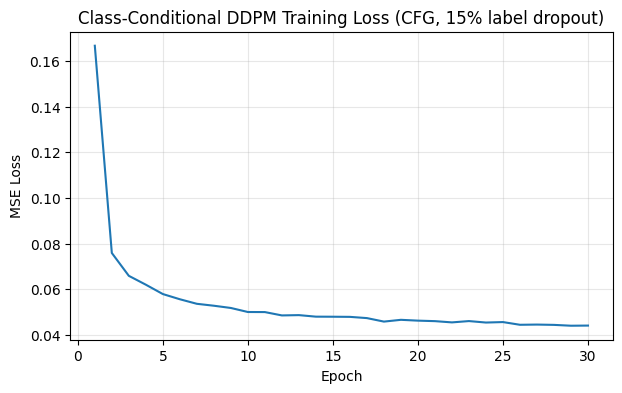

In [ ]:
# Class-conditional DDPM with classifier-free guidance: model + training
import time

NUM_CLASSES = 10
NULL_CLASS  = NUM_CLASSES   # extra index 10 = "no label" token (unconditional)
P_UNCOND    = 0.15

class ConditionalUNet(SimpleUNet):
    """SimpleUNet + class embedding added to the time embedding."""
    def __init__(self, time_dim=128, num_classes=NUM_CLASSES):
        super().__init__(time_dim)
        # num_classes + 1 so the null token has its own learned embedding
        self.class_embed = nn.Embedding(num_classes + 1, time_dim)

    def forward(self, x, t, y):
        # Condition on noise level AND class: embed both, add together
        emb = self.time_embed(t) + self.class_embed(y)

        # Encoder
        x1 = self.down1(x, emb)
        x2 = self.down2(F.max_pool2d(x1, 2), emb)
        x3 = self.down3(F.max_pool2d(x2, 2), emb)

        # Bottleneck
        x = self.bottleneck(F.max_pool2d(x3, 2), emb)

        # Decoder + skip connections
        x = F.interpolate(x, size=x3.shape[-2:], mode="nearest")
        x = self.up1(torch.cat([x, x3], dim=1), emb)
        x = F.interpolate(x, size=x2.shape[-2:], mode="nearest")
        x = self.up2(torch.cat([x, x2], dim=1), emb)
        x = F.interpolate(x, size=x1.shape[-2:], mode="nearest")
        x = self.up3(torch.cat([x, x1], dim=1), emb)

        return self.final(x)


def train_cond(model, schedule, loader, epochs=30, device=DEVICE,
               p_uncond=P_UNCOND, per_sample_drop=True):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    losses = []
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0

        for x0, y in loader:
            x0, y = x0.to(device), y.to(device)

            # Classifier-free guidance training: drop the label 15% of the time
            if per_sample_drop:   # standard: each image independently
                drop = torch.rand(y.shape[0], device=device) < p_uncond
            else:                 # literal reading: whole batch dropped together
                drop = (torch.rand((), device=device) < p_uncond).expand(y.shape[0])
            y = torch.where(drop, torch.full_like(y, NULL_CLASS), y)

            t = torch.randint(0, schedule.T, (x0.shape[0],), device=device)
            x_t, noise = schedule.q_sample(x0, t)

            loss = F.mse_loss(model(x_t, t, y), noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg = epoch_loss / len(loader)
        losses.append(avg)
        print(f"Epoch {epoch:2d}/{epochs} | Loss: {avg:.4f}")

    elapsed = time.time() - t0
    print(f"Training time: {elapsed / 60:.1f} min")

    plt.figure(figsize=(7, 4))
    plt.plot(range(1, epochs + 1), losses)
    plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
    plt.title("Class-Conditional DDPM Training Loss (CFG, 15% label dropout)")
    plt.grid(alpha=0.3)
    plt.show()

    return losses, elapsed


# Train (cosine schedule, s=0.008; swap in another schedule if you prefer)
cond_model    = ConditionalUNet().to(DEVICE)
cond_schedule = cosine_schedule

cond_losses, cond_train_time = train_cond(cond_model, cond_schedule, loader, epochs=30)

In [ ]:
# Classifier-free guidance sampling + deliverables
CLASS_NAMES = dataset.classes

@torch.no_grad()
def cfg_sample(model, schedule, labels, w=3.0, seed=0, x_initial=None):
    """DDPM sampling with classifier-free guidance.
    eps = eps_uncond + w * (eps_cond - eps_uncond)
    w=0: unconditional, w=1: plain conditional, w>1: stronger guidance."""
    model.eval()
    labels = torch.as_tensor(labels, device=DEVICE).long()
    n = labels.shape[0]
    null = torch.full_like(labels, NULL_CLASS)

    betas  = schedule.betas
    alphas = 1 - betas
    ab     = schedule.alphas_cumprod

    torch.manual_seed(seed)   # also fixes the per-step noise, so w sweeps are comparable
    x = torch.randn(n, 1, 28, 28, device=DEVICE) if x_initial is None else x_initial.clone()

    for t in reversed(range(schedule.T)):
        tt = torch.full((n,), t, device=DEVICE, dtype=torch.long)

        # Run the model twice (with and without the label), batched into one call
        eps_c, eps_u = model(torch.cat([x, x]), torch.cat([tt, tt]),
                             torch.cat([labels, null])).chunk(2)
        eps = eps_u + w * (eps_c - eps_u)

        # Same DDPM update as ddpm_sample
        x = (x - betas[t] / torch.sqrt(1 - ab[t]) * eps) / torch.sqrt(alphas[t])
        if t > 0:
            x = x + torch.sqrt(betas[t]) * torch.randn_like(x)

    return x.clamp(0, 1)


def _clean(ax):
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)


# --- Deliverable 1: 5 samples of class 0 (T-shirt) and class 7 (Sneaker), w=3 ---
demo_classes = [0, 7]
demo = cfg_sample(cond_model, cond_schedule,
                  [c for c in demo_classes for _ in range(5)], w=3, seed=0).cpu()

fig, axes = plt.subplots(2, 5, figsize=(10, 4.6))
for i, ax in enumerate(axes.flat):
    ax.imshow(demo[i, 0], cmap="gray", vmin=0, vmax=1)
    _clean(ax)
for r, c in enumerate(demo_classes):
    axes[r, 0].set_ylabel(f"{c}: {CLASS_NAMES[c]}", fontsize=11, rotation=0,
                          labelpad=50, ha="right", va="center")
fig.suptitle("Class-conditional samples (CFG, w = 3)", fontsize=13)
plt.tight_layout()
plt.savefig("cfg_class_demo.png", dpi=150, bbox_inches="tight")
plt.show()


# --- Deliverable 2: guidance sweep, w = 1, 3, 7, 15, one row per class ---
W_VALUES      = [1, 3, 7, 15]
SWEEP_CLASSES = list(range(10))   # all classes; use [0, 7] for just the demo classes

# Same starting noise per class across all w, so only the guidance changes
torch.manual_seed(1)
base_noise = torch.randn(len(SWEEP_CLASSES), 1, 28, 28, device=DEVICE)

sweep = {w: cfg_sample(cond_model, cond_schedule, SWEEP_CLASSES, w=w,
                       seed=1, x_initial=base_noise).cpu()
         for w in W_VALUES}

fig, axes = plt.subplots(len(SWEEP_CLASSES), len(W_VALUES),
                         figsize=(1.9 * len(W_VALUES) + 1.5, 1.9 * len(SWEEP_CLASSES)),
                         squeeze=False)
for r, c in enumerate(SWEEP_CLASSES):
    for col, w in enumerate(W_VALUES):
        ax = axes[r, col]
        ax.imshow(sweep[w][r, 0], cmap="gray", vmin=0, vmax=1)
        _clean(ax)
        if r == 0:
            ax.set_title(f"w = {w}", fontsize=12)
    axes[r, 0].set_ylabel(f"{c}: {CLASS_NAMES[c]}", fontsize=10, rotation=0,
                          labelpad=45, ha="right", va="center")
fig.suptitle("Guidance scale sweep (same starting noise per row)", fontsize=13)
plt.tight_layout()
plt.savefig("cfg_guidance_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
# Self-contained latency test: works after a runtime reset (no trained weights needed)
import time, math
import torch, torch.nn as nn
import torch.nn.functional as F

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --- Same UNet as Variant A ---
class TimeEmbedding(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 4), nn.SiLU(),
                                 nn.Linear(dim * 4, dim))

    def forward(self, t):
        half = 128 // 2
        freq = torch.exp(-torch.arange(half, device=t.device) * (8.0 / half))
        args = t[:, None].float() * freq[None]
        return self.mlp(torch.cat([torch.cos(args), torch.sin(args)], dim=-1))


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim=128):
        super().__init__()
        self.norm1 = nn.GroupNorm(min(8, in_ch), in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(min(8, out_ch), out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_proj = nn.Linear(time_dim, out_ch)
        if in_ch != out_ch:
            self.skip = nn.Conv2d(in_ch, out_ch, 1)
        else:
            self.skip = nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_proj(t_emb)[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class SimpleUNet(nn.Module):
    def __init__(self, time_dim=128):
        super().__init__()
        self.time_embed = TimeEmbedding(time_dim)
        self.down1 = ResBlock(1, 32)
        self.down2 = ResBlock(32, 64)
        self.down3 = ResBlock(64, 128)
        self.bottleneck = ResBlock(128, 128)
        self.up1 = ResBlock(256, 128)
        self.up2 = ResBlock(192, 64)
        self.up3 = ResBlock(96, 32)
        self.final = nn.Conv2d(32, 1, 1)

    def forward(self, x, t):
        e = self.time_embed(t)
        x1 = self.down1(x, e)
        x2 = self.down2(F.max_pool2d(x1, 2), e)
        x3 = self.down3(F.max_pool2d(x2, 2), e)
        x = self.bottleneck(F.max_pool2d(x3, 2), e)
        x = F.interpolate(x, size=x3.shape[-2:])
        x = self.up1(torch.cat([x, x3], 1), e)
        x = F.interpolate(x, size=x2.shape[-2:])
        x = self.up2(torch.cat([x, x2], 1), e)
        x = F.interpolate(x, size=x1.shape[-2:])
        x = self.up3(torch.cat([x, x1], 1), e)
        return self.final(x)


# --- Cosine schedule (s = 0.008) ---
T = 1000
steps = torch.arange(T + 1, dtype=torch.float32) / T
ac = torch.cos((steps + 0.008) / 1.008 * math.pi / 2) ** 2
ac = ac / ac[0]
betas = torch.clamp(1 - ac[1:] / ac[:-1], 0, 0.999).to(DEVICE)
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, 0)


# --- Samplers ---
@torch.no_grad()
def ddpm_sample(model, x):
    for t in reversed(range(T)):
        n = x.shape[0]
        tt = torch.full((n,), t, device=DEVICE)
        eps = model(x, tt)
        coef = betas[t] / (1 - alpha_bars[t]).sqrt()
        x = (x - coef * eps) / alphas[t].sqrt()
        if t > 0:
            x = x + betas[t].sqrt() * torch.randn_like(x)
    return x


@torch.no_grad()
def ddim_sample(model, x, n_steps=50):
    ts = torch.linspace(T - 1, 0, n_steps).round().long()
    ts = torch.unique_consecutive(ts)
    for i in range(len(ts) - 1):
        t = int(ts[i])
        tn = int(ts[i + 1])
        n = x.shape[0]
        tt = torch.full((n,), t, device=DEVICE)
        eps = model(x, tt)
        x0 = (x - (1 - alpha_bars[t]).sqrt() * eps) / alpha_bars[t].sqrt()
        x0 = x0.clamp(0, 1)
        x = alpha_bars[tn].sqrt() * x0 + (1 - alpha_bars[tn]).sqrt() * eps
    return x


# --- Timing ---
@torch.no_grad()
def time_generation(fn, n_runs=5, warmup=1):
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()
    times = []
    for _ in range(n_runs):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        fn()
        torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)
    times.sort()
    return times[len(times) // 2]


# Untrained is fine: latency doesn't depend on the weights
net = SimpleUNet().to(DEVICE).eval()

def run_ddpm():
    return ddpm_sample(net, torch.randn(1, 1, 28, 28, device=DEVICE))

def run_ddim():
    return ddim_sample(net, torch.randn(1, 1, 28, 28, device=DEVICE))

ddpm_s = time_generation(run_ddpm, n_runs=3)
ddim_s = time_generation(run_ddim, n_runs=5)

print("GPU:", torch.cuda.get_device_name(0))
print(f"DDPM-1000: {ddpm_s:.2f} s per image ({ddpm_s / 1000 * 1000:.2f} ms per step)")
print(f"DDIM-50:   {ddim_s:.2f} s per image ({ddim_s / 50 * 1000:.2f} ms per step)")
print(f"Speedup DDIM-50 vs DDPM-1000: {ddpm_s / ddim_s:.1f}x")

for name, s in [("DDPM-1000", ddpm_s), ("DDIM-50", ddim_s)]:
    if s <= 1:
        print(f"  {name} at 28x28 meets the 1 s target")
    else:
        print(f"  {name} at 28x28 misses the 1 s target by {s:.1f}x")

GPU: Tesla T4
DDPM-1000: 3.82 s per image (3.82 ms per step)
DDIM-50:   0.24 s per image (4.80 ms per step)
Speedup DDIM-50 vs DDPM-1000: 15.9x
  DDPM-1000 at 28x28 misses the 1 s target by 3.8x
  DDIM-50 at 28x28 meets the 1 s target


Latency Analysis Memo: Reduced-step DDIM with VAE and Image Library
We recommend a reduced-step DDIM operating in conjunction with a VAE and cached image library to meet a one-second latency constraint for AI background generation based on user prompts, given hardware, quality, and six-week timeline constraints.
A standard DDPM (1000 steps) is almost certainly unable to meet the one-second constraint on 2x NVIDIA A10G GPUs:

1. Our experiments clocked a standard 1000-step DDPM trained on 28x28 grayscale FashionMNIST images at 3.82ms per denoising step—i.e., 3.82s for 1000 steps—on an NVIDIA T4 GPU via Google Colab.

2. Given that a single T4 needs about 3.8s to generate one 28x28 image with a 1000-step DDPM, then two A10Gs (assuming they are four times faster combined) would still need about a second for that same 28x28 image, and far longer at 512x512, as each step would require ~334 times more work per image (512x512)/(28x28).

We foresee at least two approaches to meet our one-second latency target. The first is cutting step count and resolution, e.g., from DDPM's 1000 steps to DDIM's 15—20. While a vanilla DDIM could meet our one-second latency constraint, it would likely fail our sub-30 FID constraint at a 512x512 image size, as our prior 28x28 experiments scored far higher. However, we could run the diffusion model in conjunction with a pretrained VAE—a technique called Latent Space Integration—that compresses 512x512 images to 64x64 during training and sampling, thereby cutting compute by ~64x. Doing so would buy more training and more steps per time unit, thereby tactically lowering FID by affording a bigger, better-trained model, while also strategically rendering our six-week ship timeline feasible via drastically reduced training time.

The second approach, recommended as a fallback, is related in that it would rely on a reduced-step DDIM while fetching as opposed to generating more common image prompts, e.g., beach or night sky—a technique we call cache-first DDIM, or a class-labeled library of pre-generated backgrounds with a prompt-guided VAE-wrapped model sampled via a low-latency 15—20 step DDIM for user requests outside the image cache. When a user types, the prompt is matched against a pre-generated class-labeled library; the closest matched image is shown almost immediately. Only prompts with no close match fall back to 15—20-step class-conditioned DDIM generation. While we can neither provide exact FID deltas nor precise per-hour implementation estimates for either approach, model-tuning and generic-background compiling should be as salutary for FID scores as they are relatively cheap to implement timewise.

We flag two quality risks. First, a user may receive a cached sunny-day background instead of a requested morning-dawn image. We could mitigate perceived product failure in this scenario by rendering cached images falling below a certain threshold of a prompt-to-image match score as mere "previews," while a right-sized DDIM generation runs in the background as users type. Second, relatively low DDIM steps may excessively reduce image quality, as fewer steps (about a dozen vs a thousand with DDPM) typically jettison finer details. If a sub-30 FID is deemed user-paramount, then increased step count improving FID must be traded at the expense of latency (absent the employment of a superior model, noted above); for users, a quick low-step image could display while typing, replaced by a sharper higher-step version once typing halts.


---
## Submission
- [ ] Push to `genai-course/week2/homework/notebook.ipynb`
- [ ] Loss curve plotted
- [ ] Schedule comparison visualised
- [ ] DDIM vs DDPM timing + quality comparison